In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
pd.set_option("display.max_columns", None)

In [ ]:
# Read the Excel file
import pandas as pd

df = pd.read_excel("../data/raw/data.xlsx", engine="openpyxl")
print(df.head())

         TransactionId         BatchId       AccountId       SubscriptionId  \
0  TransactionId_76871   BatchId_36123  AccountId_3957   SubscriptionId_887   
1  TransactionId_73770   BatchId_15642  AccountId_4841  SubscriptionId_3829   
2  TransactionId_26203   BatchId_53941  AccountId_4229   SubscriptionId_222   
3    TransactionId_380  BatchId_102363   AccountId_648  SubscriptionId_2185   
4  TransactionId_28195   BatchId_38780  AccountId_4841  SubscriptionId_3829   

        CustomerId CurrencyCode  CountryCode    ProviderId     ProductId  \
0  CustomerId_4406          UGX          256  ProviderId_6  ProductId_10   
1  CustomerId_4406          UGX          256  ProviderId_4   ProductId_6   
2  CustomerId_4683          UGX          256  ProviderId_6   ProductId_1   
3   CustomerId_988          UGX          256  ProviderId_1  ProductId_21   
4   CustomerId_988          UGX          256  ProviderId_4   ProductId_6   

      ProductCategory    ChannelId   Amount  Value  TransactionStart

In [19]:
#Dataset Overview
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

#Data Types
print(df.dtypes)
#Duplicate Records
print(f"Duplicate Records: {df.duplicated().sum()}")
#Missing Values
print(df.isnull().sum())
#Numerical Features
df.describe().T
#Categorical Features
df.describe(include="object").T

#

Rows: 95662
Columns: 16
TransactionId            object
BatchId                  object
AccountId                object
SubscriptionId           object
CustomerId               object
CurrencyCode             object
CountryCode               int64
ProviderId               object
ProductId                object
ProductCategory          object
ChannelId                object
Amount                  float64
Value                     int64
TransactionStartTime     object
PricingStrategy           int64
FraudResult               int64
dtype: object
Duplicate Records: 0
TransactionId           0
BatchId                 0
AccountId               0
SubscriptionId          0
CustomerId              0
CurrencyCode            0
CountryCode             0
ProviderId              0
ProductId               0
ProductCategory         0
ChannelId               0
Amount                  0
Value                   0
TransactionStartTime    0
PricingStrategy         0
FraudResult             0
dtype: int64


,count,unique,top,freq
TransactionId,95662,95662,TransactionId_76871,1
BatchId,95662,94809,BatchId_67019,28
AccountId,95662,3633,AccountId_4841,30893
SubscriptionId,95662,3627,SubscriptionId_3829,32630
CustomerId,95662,3742,CustomerId_7343,4091
CurrencyCode,95662,1,UGX,95662
ProviderId,95662,6,ProviderId_4,38189
ProductId,95662,23,ProductId_6,32635
ProductCategory,95662,9,financial_services,45405
ChannelId,95662,4,ChannelId_3,56935


In [ ]:
#missing values
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing = missing[missing > 0]

missing

Series([], dtype: int64)

In [21]:
#missing persentage
missing_pct = (
    df.isnull().mean() * 100
).sort_values(ascending=False)

missing_pct[missing_pct > 0]

Series([], dtype: float64)

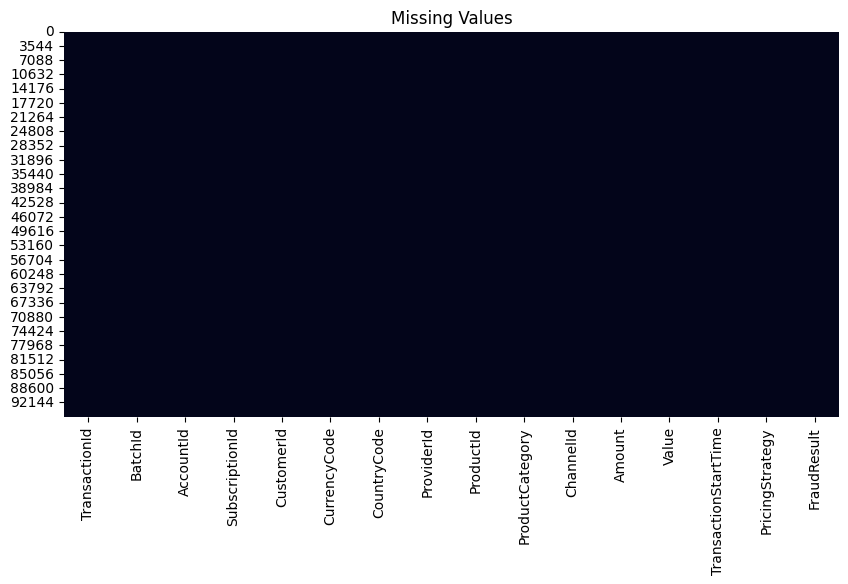

In [22]:
plt.figure(figsize=(10,5))

sns.heatmap(
    df.isnull(),
    cbar=False
)

plt.title("Missing Values")
plt.show()

In [ ]:
#Numerical Feature Distributions
numerical_cols = df.select_dtypes(
    include=np.number
).columns

numerical_cols

Index(['CountryCode', 'Amount', 'Value', 'PricingStrategy', 'FraudResult'], dtype='object')

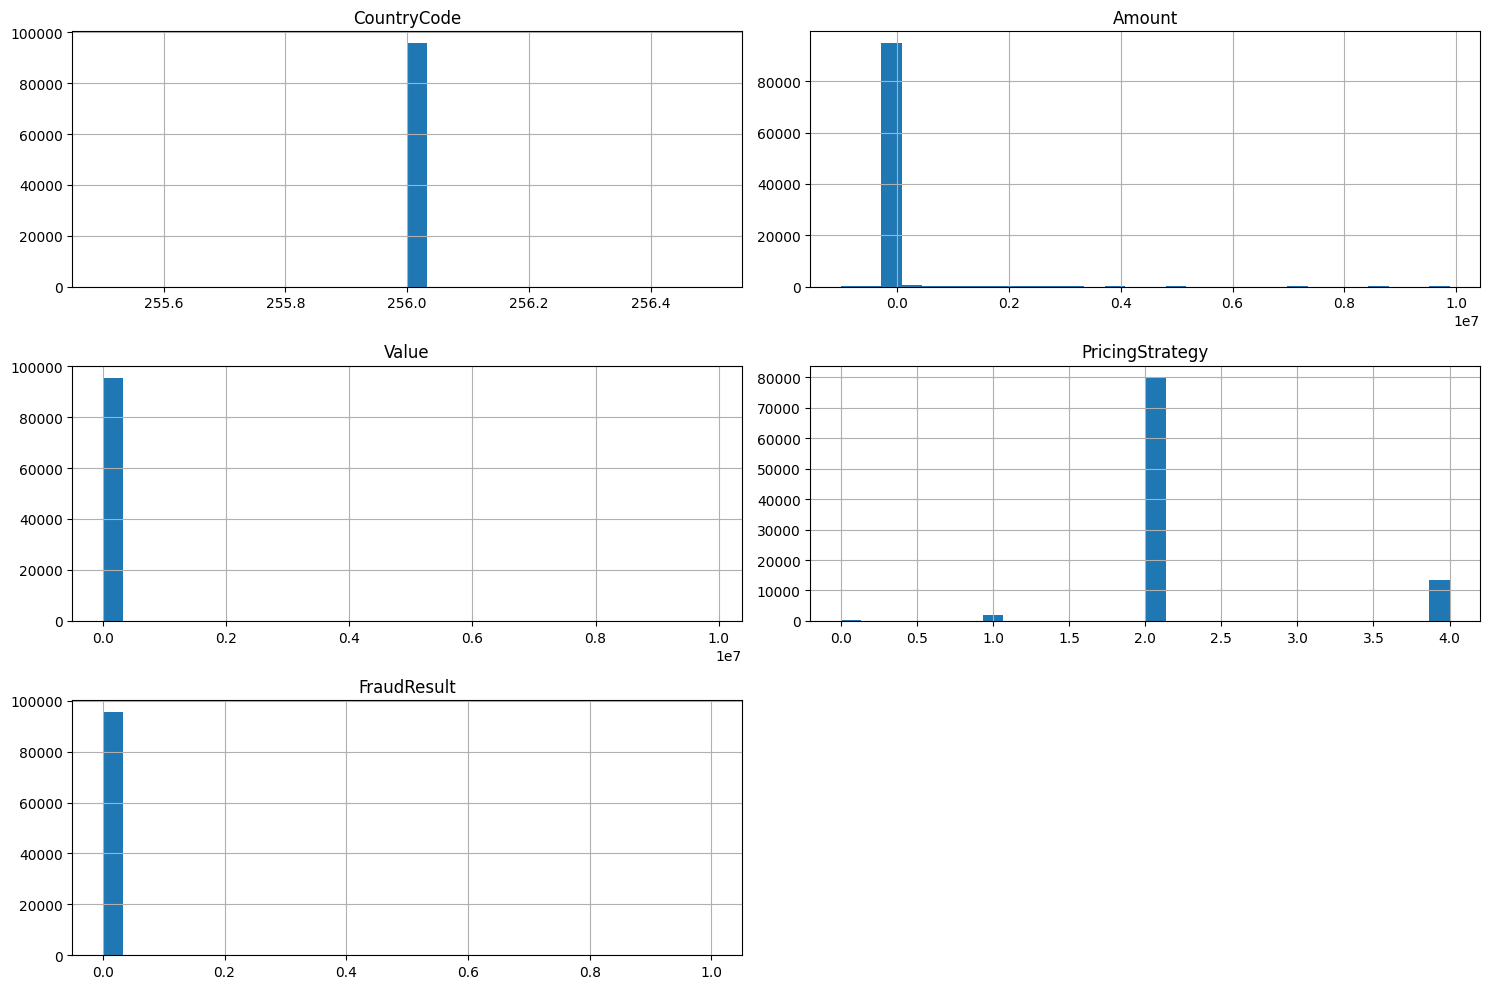

In [24]:
df[numerical_cols].hist(
    figsize=(15,10),
    bins=30
)

plt.tight_layout()
plt.show()

In [ ]:
#Outlier Detection
important_num = [
    "Amount",
    "Value"
]

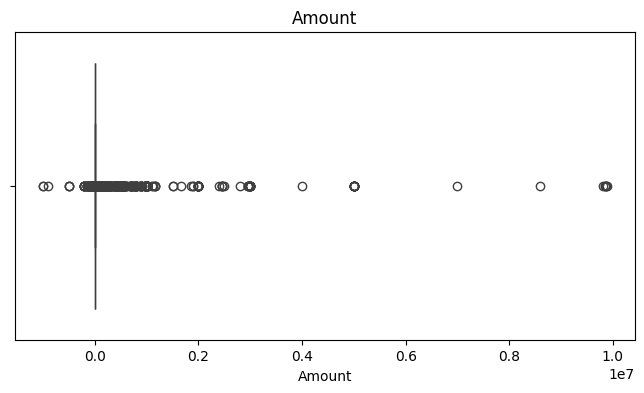

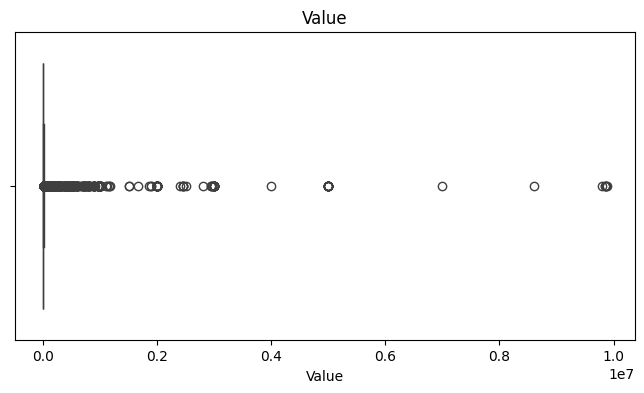

In [26]:
for col in important_num:

    plt.figure(figsize=(8,4))

    sns.boxplot(
        x=df[col]
    )

    plt.title(col)

    plt.show()

In [ ]:
#Identify categorical variables:
cat_cols = df.select_dtypes(
    include="object"
).columns

cat_cols

Index(['TransactionId', 'BatchId', 'AccountId', 'SubscriptionId', 'CustomerId',
       'CurrencyCode', 'ProviderId', 'ProductId', 'ProductCategory',
       'ChannelId', 'TransactionStartTime'],
      dtype='object')

In [28]:
#Value Counts
for col in cat_cols:

    print("\n")
    print(col)

    print(df[col].value_counts().head(10))



TransactionId
TransactionId
TransactionId_76871     1
TransactionId_73770     1
TransactionId_26203     1
TransactionId_380       1
TransactionId_28195     1
TransactionId_23223     1
TransactionId_118063    1
TransactionId_100640    1
TransactionId_51905     1
TransactionId_130161    1
Name: count, dtype: int64


BatchId
BatchId
BatchId_67019     28
BatchId_51870     16
BatchId_113893    14
BatchId_127204    12
BatchId_116835    10
BatchId_88001      9
BatchId_49408      7
BatchId_110084     7
BatchId_34879      6
BatchId_86880      6
Name: count, dtype: int64


AccountId
AccountId
AccountId_4841    30893
AccountId_4249     4457
AccountId_4840     1738
AccountId_3206     1105
AccountId_318      1070
AccountId_10        965
AccountId_3595      465
AccountId_751       411
AccountId_2648      359
AccountId_2314      356
Name: count, dtype: int64


SubscriptionId
SubscriptionId
SubscriptionId_3829    32630
SubscriptionId_4429     4457
SubscriptionId_1372     1105
SubscriptionId_3087    

In [29]:
#Visualization
important_cat = [
    "ProductCategory",
    "ChannelId",
    "PricingStrategy"
]

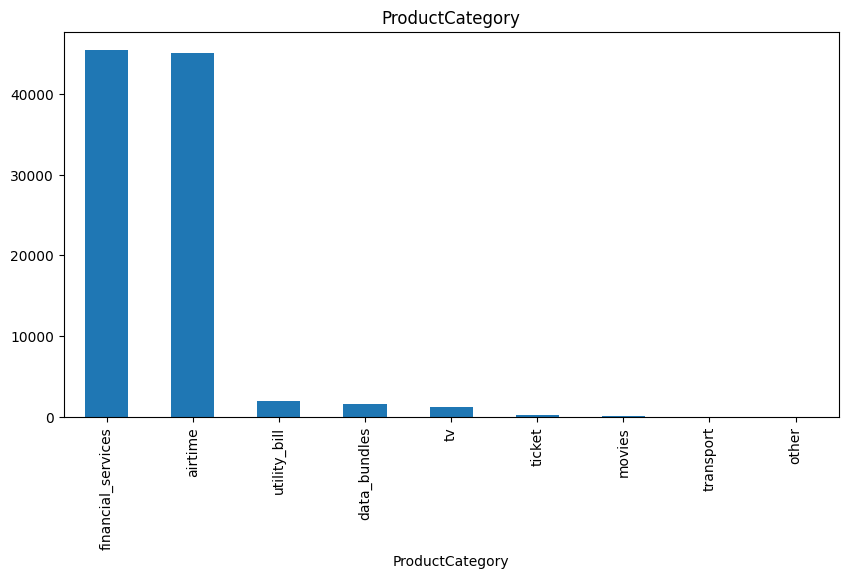

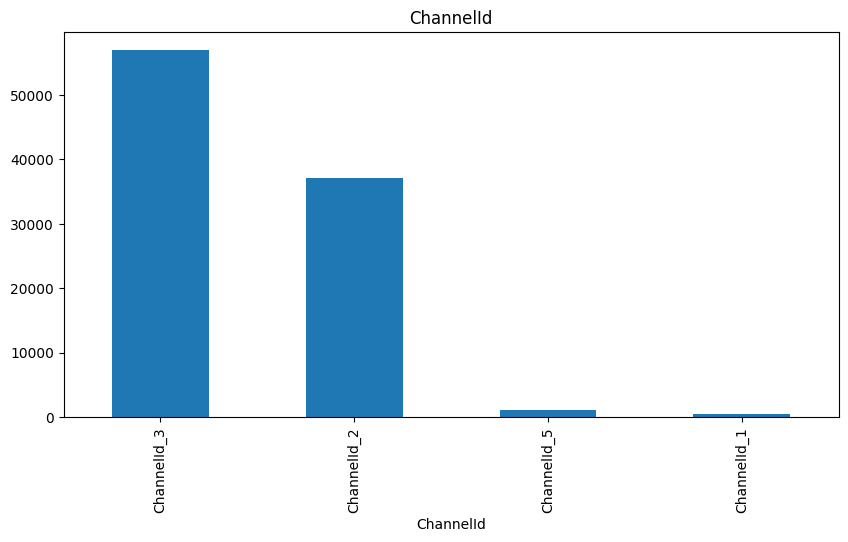

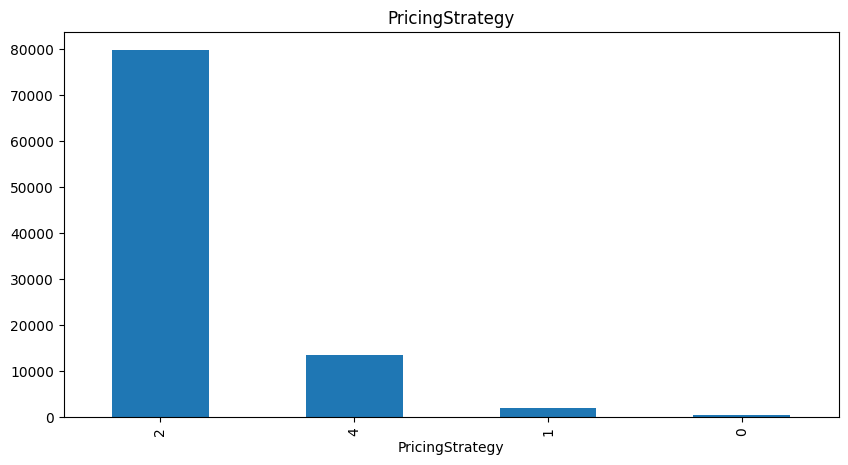

In [30]:
for col in important_cat:

    plt.figure(figsize=(10,5))

    df[col].value_counts().head(10).plot(
        kind="bar"
    )

    plt.title(col)

    plt.show()

In [32]:
#FraudResult anlsysis
df["FraudResult"].value_counts(normalize=True)*100

FraudResult
0    99.798248
1     0.201752
Name: proportion, dtype: float64

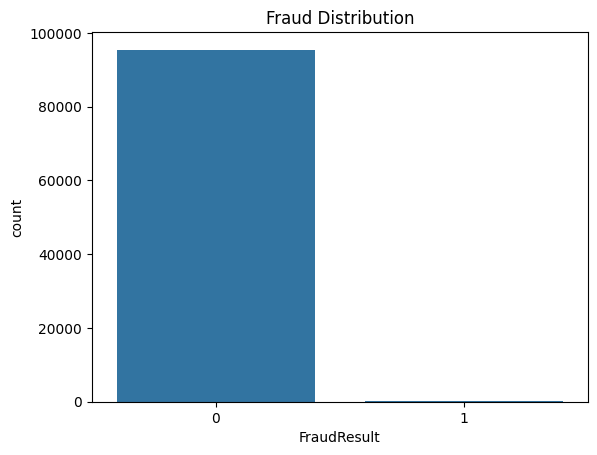

In [ ]:
#fraud distribution
sns.countplot(
    data=df,
    x="FraudResult"
)

plt.title("Fraud Distribution")
plt.show()

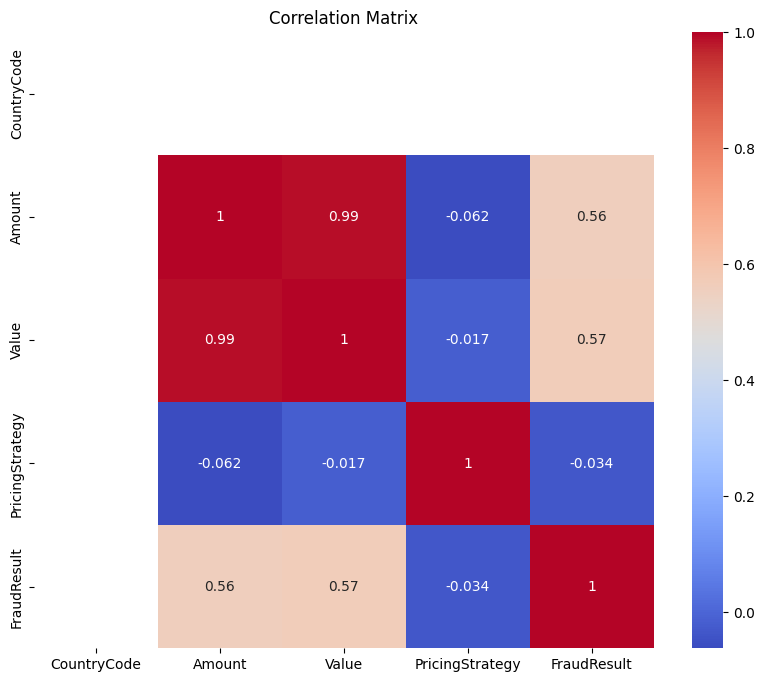

In [34]:
#Correlation Analysis
corr = df[numerical_cols].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [35]:
#Time-Based Analysis
df["TransactionStartTime"] = pd.to_datetime(
    df["TransactionStartTime"]
)

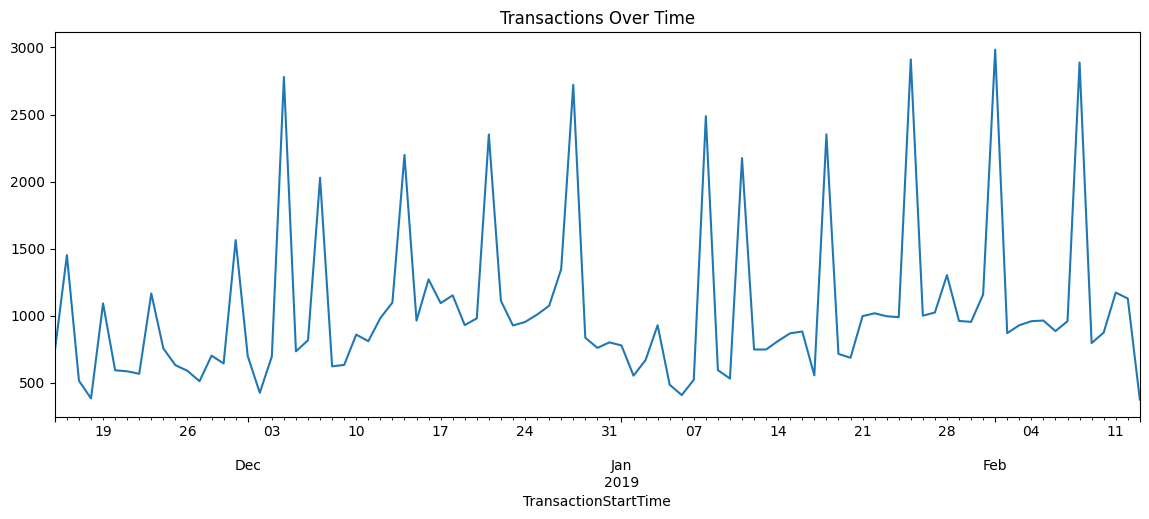

In [36]:
#Transactions Over Time
daily_transactions = (
    df
    .set_index("TransactionStartTime")
    .resample("D")
    .size()
)

daily_transactions.plot(
    figsize=(14,5)
)

plt.title("Transactions Over Time")

plt.show()

In [42]:
#Customer Analysis
df["CustomerId"].nunique()


3742

In [43]:
#Transactions per customer:
customer_txn = (
    df.groupby("CustomerId")
      .size()
)

In [44]:
customer_txn.describe()

count    3742.000000
mean       25.564404
std        96.929602
min         1.000000
25%         2.000000
50%         7.000000
75%        20.000000
max      4091.000000
dtype: float64

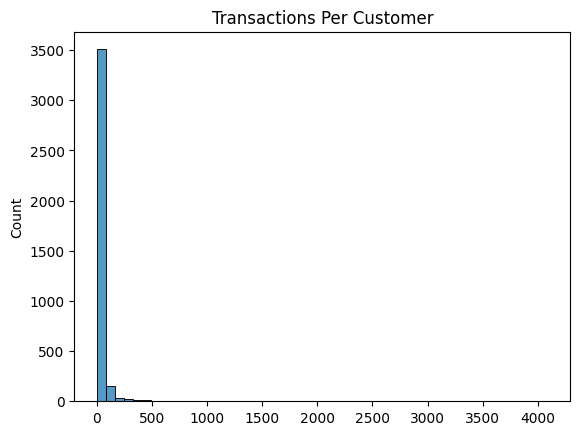

In [45]:
sns.histplot(
    customer_txn,
    bins=50
)

plt.title("Transactions Per Customer")

plt.show()

In [ ]:
# Key Insights

### 1. Transaction Amounts Are Highly Skewed
Amount and Value exhibit strong right-skewness with several extreme outliers, indicating the need for scaling and potentially log transformation during feature engineering.

### 2. Customer Activity Is Unevenly Distributed
A small number of customers generate many transactions while most customers transact infrequently, suggesting customer behavior can be a strong predictor of risk.

### 3. Fraud Cases Are Rare
The FraudResult variable is highly imbalanced, which may require stratified sampling and robust evaluation metrics when used as a feature.

### 4. Time-Based Patterns Exist
Transaction activity varies across time, indicating temporal features such as hour, day, and month may improve predictive performance.

### 5. Customer Behavior Can Support Proxy Risk Labels
The distribution of transaction frequency and monetary activity suggests that RFM analysis can effectively segment customers into engagement groups for proxy risk labeling.